In [1]:
import pandas as pd
import requests
from tqdm import tqdm
import time
from Bio import AlignIO
import numpy as np
from collections import Counter
import math

## TOP300

count    60000.000000
mean         2.721306
std          0.959521
min         -2.349994
25%          2.455079
50%          3.035641
75%          3.352755
max          3.723684
Name: ESM, dtype: float64


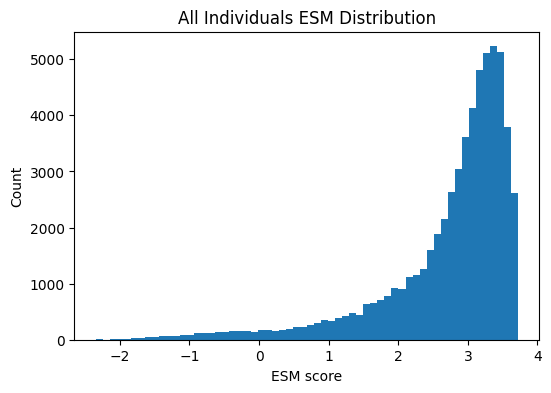

count    60000.000000
mean         2.721306
std          0.959521
min         -2.349994
25%          2.455079
50%          3.035641
75%          3.352755
max          3.723684
Name: ESM, dtype: float64


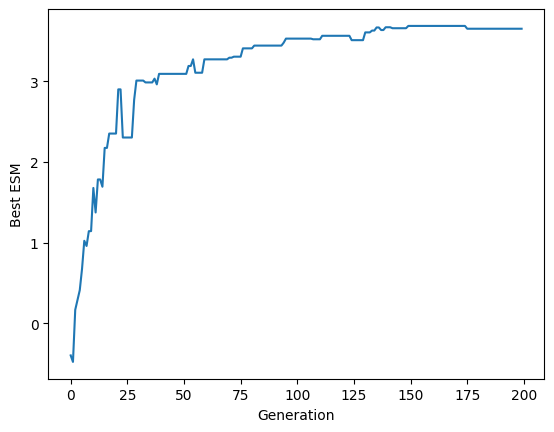

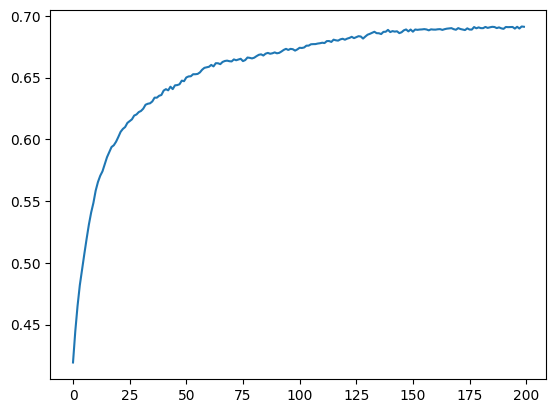

In [2]:
df=pd.read_csv("GA_population_history.csv")
print(df["ESM"].describe())


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_population_history.csv")

plt.figure(figsize=(6,4))
plt.hist(df["ESM"], bins=60)
plt.xlabel("ESM score")
plt.ylabel("Count")
plt.title("All Individuals ESM Distribution")
plt.show()

print(df["ESM"].describe())

history = pd.read_csv("GA_history.csv")

plt.plot(history["Generation"], history["Best_ESM"])
plt.xlabel("Generation")
plt.ylabel("Best ESM")
plt.show()


plt.plot(history["Generation"], history["Mean_Fitness"])

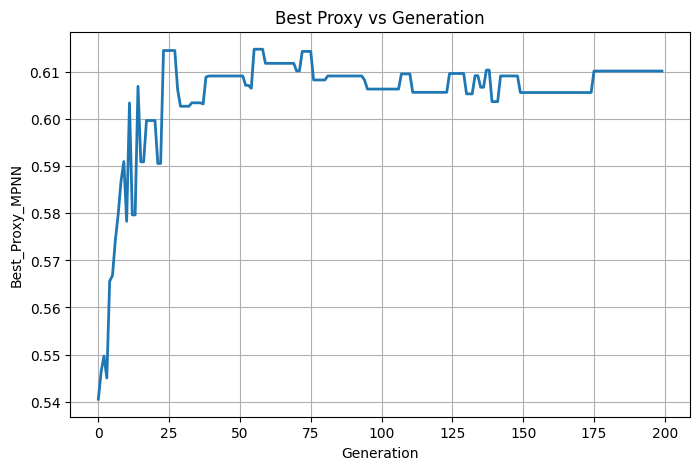

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_history.csv")

plt.figure(figsize=(8,5))
plt.plot(df["Generation"], df["Best_Proxy_MPNN"], linewidth=2)

plt.xlabel("Generation")
plt.ylabel("Best_Proxy_MPNN")
plt.title("Best Proxy vs Generation")
plt.grid(True)

plt.show()

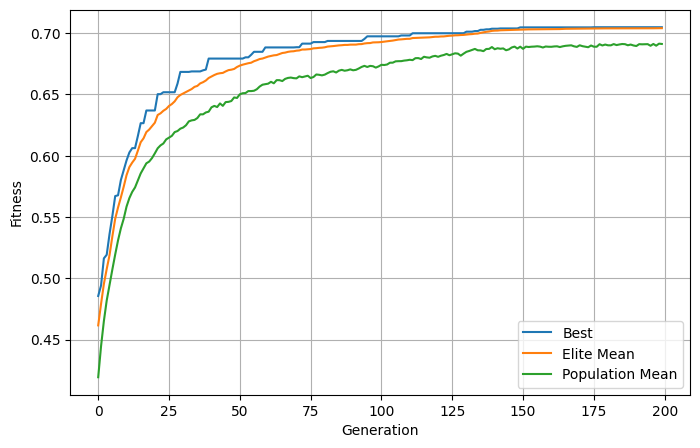

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_history.csv")

plt.figure(figsize=(8,5))

plt.plot(df["Generation"], df["Best_Fitness"], label="Best")
plt.plot(df["Generation"], df["Elite_Fitness"], label="Elite Mean")
plt.plot(df["Generation"], df["Mean_Fitness"], label="Population Mean")

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
import pandas as pd
import torch
from transformers import AutoTokenizer,EsmForMaskedLM
from tqdm import tqdm
import os,re

# =====================================================
# device
# =====================================================
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:",device)

if device.type=="cuda":
    torch.backends.cuda.matmul.allow_tf32=True

# =====================================================
# WT sequence
# =====================================================
wt_seq="MFLRREFGAVAALSVLAHAAPAPAPMQRRDISSTVLDNIDLFAQYSAAAYCSSNIESTGTTLTCDVGNCPLVEAAGATTIDEFDDTSSYGDPTGFIAVDPTNELIVLSFRGSSDLSNWIADLNFGLTSVSSICDGCEMHKGFYEAWEVIADTITSKVEAAVSSYPDYTLVFTGHSYGAALAAVAATVLRNAGYTLDLYNFGQPRIGNLALADYITGQNMGSNYRVTHTDDIVPKLPPELLGYHHFSPEYWITSGNDVTVTTSDVTEVVGVDSTAGNDGTLLDSTTAHRWYTIYISECS"

# =====================================================
# load ESM1v
# =====================================================
model_dir="../esm1v"

if not os.path.exists(model_dir):
    raise FileNotFoundError(model_dir)

tokenizer=AutoTokenizer.from_pretrained(model_dir)

model=EsmForMaskedLM.from_pretrained(model_dir).to(device)

if device.type=="cuda":
    model=model.half()

model.eval()

print("✓ ESM1v loaded")

# =====================================================
# load Top300
# =====================================================
top=pd.read_csv(
    "Top300_GA_ESM_ThermoMPNN.csv"
)

# 保存GA原始排名
top["GA_Rank"]=top["Rank"]

# =====================================================
# build variant sequence
# =====================================================
def build_variant(mut_string):

    seq=list(wt_seq)

    for m in mut_string.split(";"):

        wt_mut=m.split(">")

        if len(wt_mut)!=2:
            continue

        wt_part=wt_mut[0]
        mut_aa=wt_mut[1]

        pos=int(
            re.findall(
                r"\d+",
                wt_part
            )[0]
        )

        seq[pos-1]=mut_aa

    return "".join(seq)


# =====================================================
# full sequence PLL
# =====================================================
def compute_pll(seq,batch_size=32):

    masked_seqs=[]

    for i in range(len(seq)):

        tmp=list(seq)

        tmp[i]=tokenizer.mask_token

        masked_seqs.append(
            "".join(tmp)
        )

    total_score=0

    for start in range(
        0,
        len(masked_seqs),
        batch_size
    ):

        batch=masked_seqs[start:start+batch_size]

        inputs=tokenizer(
            batch,
            return_tensors="pt",
            padding=True
        )

        inputs={
            k:v.to(device)
            for k,v in inputs.items()
        }

        with torch.no_grad():

            if device.type=="cuda":

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):
                    logits=model(**inputs).logits

            else:
                logits=model(**inputs).logits


        log_probs=torch.log_softmax(
            logits.float(),
            dim=-1
        )

        for j in range(len(batch)):

            seq_pos=start+j

            aa=seq[seq_pos]

            aa_id=tokenizer.convert_tokens_to_ids(
                aa
            )

            score=log_probs[
                j,
                seq_pos+1,
                aa_id
            ]

            total_score+=score.item()

    return total_score/len(seq)


# =====================================================
# WT PLL
# =====================================================
print("\nComputing WT PLL...")

wt_pll=compute_pll(
    wt_seq
)

print(
    f"WT PLL={wt_pll:.4f}"
)


# =====================================================
# variant PLL
# =====================================================
pll=[]
delta=[]
seqs=[]

print("\nComputing variant PLL...")

for muts in tqdm(top["Mutations"]):

    seq=build_variant(
        muts
    )

    seqs.append(seq)

    score=compute_pll(
        seq
    )

    pll.append(score)

    delta.append(
        score-wt_pll
    )


top["Sequence"]=seqs
top["WT_PLL"]=wt_pll
top["ESM_PLL"]=pll
top["Delta_PLL"]=delta


# =====================================================
# normalize Delta PLL
# =====================================================
top["Delta_PLL_norm"]=(
    top["Delta_PLL"]
    -
    top["Delta_PLL"].min()
)/(
    top["Delta_PLL"].max()
    -
    top["Delta_PLL"].min()
    +
    1e-8
)


# =====================================================
# sort by PLL
# =====================================================
top=top.sort_values(
    "ESM_PLL",
    ascending=False
).reset_index(drop=True)


top.insert(
    0,
    "PLL_Rank",
    range(
        1,
        len(top)+1
    )
)


# =====================================================
# save
# =====================================================
out_file="Top300_ESM_PLL_ranked.csv"

top.to_csv(
    out_file,
    index=False
)


print("\nTop10:")
print(
    top[
        [
            "PLL_Rank",
            "GA_Rank",
            "Fitness",
            "ESM_PLL",
            "Delta_PLL",
            "Mutations"
        ]
    ].head(10)
)


print("\nFinished")
print(
    "Saved:",
    out_file
)

device: cuda


Some weights of EsmForMaskedLM were not initialized from the model checkpoint at ../esm1v and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ ESM1v loaded

Computing WT PLL...
WT PLL=-1.5286

Computing variant PLL...


100%|██████████| 300/300 [40:48<00:00,  8.16s/it]


Top10:
   PLL_Rank  GA_Rank   Fitness   ESM_PLL  Delta_PLL  \
0         1      128  0.702486 -1.174318   0.354300   
1         2        1  0.704846 -1.175122   0.353496   
2         3       77  0.702945 -1.175722   0.352896   
3         4       13  0.704109 -1.177133   0.351485   
4         5       38  0.703532 -1.177137   0.351481   
5         6      129  0.702482 -1.177383   0.351235   
6         7       89  0.702777 -1.178322   0.350296   
7         8       41  0.703507 -1.179164   0.349454   
8         9       43  0.703465 -1.179223   0.349395   
9        10      260  0.701748 -1.179495   0.349122   

                                           Mutations  
0  39I>L;40D>T;56E>T;66V>A;82E>T;92P>T;100P>H;103...  
1  39I>L;40D>T;56E>T;66V>A;82E>T;92P>T;100P>H;103...  
2  39I>L;40D>T;56E>T;66V>A;79T>L;82E>T;92P>T;100P...  
3  39I>L;40D>T;56E>T;66V>A;79T>L;82E>T;92P>T;100P...  
4  39I>L;40D>T;56E>T;66V>A;82E>T;92P>T;100P>H;103...  
5  39I>L;40D>T;56E>T;82E>T;92P>T;100P>H;103E>K;11...  
6